# Parameter Golf — Step 3: Low-Overhead Techniques

Step 2 failed because EMA (32% step loss) and QAT (8% step loss) killed throughput. Step 3 uses only techniques with <2ms overhead + free post-training optimizations.

**Key insight from PRs:** In 10-min budget, 1ms/step overhead = 0.006 BPB cost. Throughput is everything.

**What changed vs Step 2:**
- NO EMA (use Tight SWA instead — zero overhead)
- NO QAT during training (use GPTQ-lite post-training — zero step cost)
- Same 2000 iters / 5 shards for fair comparison to Step 1.5 and Step 2

## 1. Install Dependencies

In [1]:
!pip install -q torch numpy tqdm huggingface-hub sentencepiece

## 2. Clone Repo & Download Data

In [2]:
import os

REPO_DIR = "/content/parameter-golf"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/openai/parameter-golf.git {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/parameter-golf'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 426 (delta 0), reused 0 (delta 0), pack-reused 424 (from 2)
Receiving objects: 100% (426/426), 778.63 KiB | 32.44 MiB/s, done.
Resolving deltas: 100% (192/192), done.
Working directory: /content/parameter-golf


In [3]:
# Download training shards + validation + tokenizer
# 5 shards (~1GB) for fast directional experiments. Increase for final runs (max 80).
TRAIN_SHARDS = 5

!python data/cached_challenge_fineweb.py --train-shards {TRAIN_SHARDS}

manifest.json: 1.93kB [00:00, 7.95MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 124M/124M [00:02<00:00, 61.2MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 124MB/s] 
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s] 
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s] 
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/tokenizers/fineweb_1024_bpe.mod(…): 100% 254k/254k [00:00<00:00, 417kB/s] 
fineweb_1024_bpe.vocab: 9.86kB [00:00, 27.9MB/s]


## 3. Detect GPU & Configure Hyperparameters

In [4]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Go to Runtime > Change runtime type > GPU")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
compute_cap = torch.cuda.get_device_capability(0)
supports_flash = compute_cap[0] >= 8  # Ampere+ (sm80)

print(f"GPU: {gpu_name}")
print(f"Memory: {gpu_mem_gb:.1f} GB")
print(f"Compute capability: {compute_cap[0]}.{compute_cap[1]}")
print(f"Flash attention: {'yes' if supports_flash else 'no (will use mem_efficient)'}")
print()

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB
Compute capability: 8.0
Flash attention: yes



In [5]:
# ============================================================
# STEP 2 CONFIG: Build on Step 1 best result (combined_best)
# ============================================================

# Load Step 1 results
import json as jsonlib
import glob as globmod

STEP1_DIR = "experiments"
DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments"

step1_results = {}
for base_dir in [STEP1_DIR, DRIVE_DIR]:
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        step1_results[r["experiment"]] = r

if step1_results:
    ranked = sorted(step1_results.values(), key=lambda r: r.get("val_bpb", 999))
    print("Step 1 Results:")
    print(f"{'Experiment':<22} {'BPB':>8}")
    print("-" * 32)
    for r in ranked:
        print(f"{r['experiment']:<22} {r.get('val_bpb', 0):>8.4f}")
    print(f"\nBest: {ranked[0]['experiment']} (BPB={ranked[0].get('val_bpb', '?')})")
else:
    print("No Step 1 results found. Using default combined_best config.")

# Base config = Step 1 winner (combined_best)
BASE_CONFIG = {
    "NUM_LAYERS":         "10",
    "MLP_MULT":           "3",
    "MODEL_DIM":          "512",
    "NUM_HEADS":          "8",
    "NUM_KV_HEADS":       "4",
    "TRAIN_SEQ_LEN":      "2048",
    "MATRIX_LR":          "0.02",
    "SCALAR_LR":          "0.02",
    "TIED_EMBED_LR":      "0.03",
    "WARMDOWN_ITERS":     "800",
    "MUON_MOMENTUM":      "0.99",
    "MUON_MOMENTUM_WARMUP_START": "0.92",
    "MUON_MOMENTUM_WARMUP_STEPS": "500",
    "GRAD_CLIP_NORM":     "0.3",
}

# GPU-specific batch settings
if gpu_mem_gb >= 70:    PROFILE = "h100"
elif gpu_mem_gb >= 35:  PROFILE = "a100"
elif gpu_mem_gb >= 20:  PROFILE = "l4"
else:                   PROFILE = "t4"

BATCH_SETTINGS = {
    "t4":   {"TRAIN_BATCH_TOKENS": "131072",  "VAL_BATCH_SIZE": "131072"},
    "l4":   {"TRAIN_BATCH_TOKENS": "524288",  "VAL_BATCH_SIZE": "262144"},
    "a100": {"TRAIN_BATCH_TOKENS": "262144",  "VAL_BATCH_SIZE": "262144"},  # halved for speed
    "h100": {"TRAIN_BATCH_TOKENS": "524288",  "VAL_BATCH_SIZE": "524288"},
}

FAST_SETTINGS = {
    "ITERATIONS":           "2000",
    "WARMDOWN_ITERS":       "400",
    "MAX_WALLCLOCK_SECONDS": "600",
    "VAL_LOSS_EVERY":       "500",
    "TRAIN_LOG_EVERY":      "100",
}

print(f"\nStep 2 base: combined_best + {PROFILE} batch settings")
print(f"Fast mode: {FAST_SETTINGS['ITERATIONS']} iterations")

No Step 1 results found. Using default combined_best config.

Step 2 base: combined_best + a100 batch settings
Fast mode: 2000 iterations


## 4. Patch train_gpt.py for Single-GPU Speed

In [6]:
# Patch train_gpt.py for single-GPU speed:
# 1. Flash SDP fallback for T4/older GPUs
# 2. Reduce grad_accum from 8 to 4 → 2x faster steps, better VRAM usage

def apply_base_patches():
    with open("train_gpt.py", "r") as f:
        code = f.read()
    patched = False

    # Patch 1: SDP backend fallback (T4 only)
    if not supports_flash:
        old_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(True)
    enable_mem_efficient_sdp(False)
    enable_math_sdp(False)"""
        new_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(False)
    enable_mem_efficient_sdp(True)
    enable_math_sdp(True)"""
        if old_sdp in code:
            code = code.replace(old_sdp, new_sdp)
            print("Patched: flash_sdp -> mem_efficient_sdp (non-flash GPU)")
            patched = True

    # Patch 2: Reduce grad_accum_steps for single GPU
    GRAD_ACCUM = 8  # keep original — torch.compile disabled makes steps fast enough

    old_check = '    if 8 % world_size != 0:\n        raise ValueError(f"WORLD_SIZE={world_size} must divide 8 so grad_accum_steps stays integral")\n    grad_accum_steps = 8 // world_size'
    new_check = f'    grad_accum_steps = {GRAD_ACCUM}  # patched: was 8//world_size'
    if old_check in code:
        code = code.replace(old_check, new_check)
        print(f"Patched: grad_accum_steps = {GRAD_ACCUM} (was 8, 2x faster)")
        patched = True

    old_scale = "    grad_scale = 1.0 / grad_accum_steps"
    new_scale = f"    grad_scale = 1.0 / {GRAD_ACCUM}  # patched"
    if old_scale in code:
        code = code.replace(old_scale, new_scale)

    # Patch 3: Disable torch.compile (saves 5-10 min compilation per experiment)
    old_compile = "    compiled_model = torch.compile(base_model, dynamic=False, fullgraph=True)"
    new_compile = "    compiled_model = base_model  # torch.compile disabled for fast experiments"
    if old_compile in code:
        code = code.replace(old_compile, new_compile)
        print("Patched: torch.compile disabled (faster startup)")
        patched = True

    # Also disable Newton-Schulz compilation
    old_ns = "    zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)"
    new_ns = "    # zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)  # disabled"
    if old_ns in code:
        code = code.replace(old_ns, new_ns)

    if patched:
        with open("train_gpt.py", "w") as f:
            f.write(code)
    else:
        print("No patches needed (already applied or script changed)")

apply_base_patches()

Patched: grad_accum_steps = 8 (was 8, 2x faster)
Patched: torch.compile disabled (faster startup)


## 5. Step 3 Experiments

12 experiments: low-overhead individual tests, progressive stacks, and free post-training optimizations.
All use identical settings to Step 2 (2000 iters, 5 shards) for fair comparison.

### Patch Functions

Low-overhead patches only. No EMA, no full QAT.

In [7]:
import subprocess, math

def reset_script():
    subprocess.run(["git", "checkout", "train_gpt.py"], check=True, capture_output=True)

def read_script():
    with open("train_gpt.py", "r") as f:
        return f.read()

def write_script(code):
    with open("train_gpt.py", "w") as f:
        f.write(code)

def patch_replace(code, old, new, label=""):
    if old not in code:
        print(f"  WARN: patch target not found ({label})")
        return code
    return code.replace(old, new, 1)

# ===== KEPT FROM STEP 1/2 (proven, low overhead) =====

def patch_ortho_init(code):
    old = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        for module in self.modules():
            if isinstance(module, nn.Linear) and getattr(module, "_zero_init", False):
                nn.init.zeros_(module.weight)'''
    new = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        num_layers = len(self.blocks)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if getattr(module, "_zero_init", False):
                    nn.init.zeros_(module.weight)
                elif module.weight.ndim == 2 and min(module.weight.shape) > 1:
                    nn.init.orthogonal_(module.weight, gain=1.0)
                    if hasattr(module, "_zero_init") and not module._zero_init:
                        module.weight.data *= 1.0 / (2 * num_layers) ** 0.5'''
    return patch_replace(code, old, new, "ortho_init")

def patch_smeargate(code):
    old = '''class Block(nn.Module):'''
    new = '''class SmearGate(nn.Module):
    def __init__(self, dim: int, init_keep: float = 0.95):
        super().__init__()
        init_val = math.log(init_keep / (1 - init_keep))
        self.gate = nn.Parameter(torch.full((dim,), init_val, dtype=torch.float32))
    def forward(self, x: Tensor) -> Tensor:
        g = torch.sigmoid(self.gate.to(dtype=x.dtype))[None, None, :]
        x_prev = torch.cat([x[:, :1, :], x[:, :-1, :]], dim=1)
        return g * x + (1 - g) * x_prev


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "smeargate class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.smear_gate = SmearGate(model_dim)\n        self.final_norm = RMSNorm()", "smeargate init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids)
        x = self.smear_gate(x)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "smeargate forward")

def patch_bigram_hash(code):
    old = '''class Block(nn.Module):'''
    new = '''class BigramHash(nn.Module):
    def __init__(self, vocab_size: int, dim: int, num_buckets: int = 4096, hash_dim: int = 128):
        super().__init__()
        self.num_buckets = num_buckets
        self.hash_table = nn.Embedding(num_buckets, hash_dim)
        self.proj = CastedLinear(hash_dim, dim, bias=False)
        nn.init.normal_(self.hash_table.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)
    def forward(self, input_ids: Tensor) -> Tensor:
        prev_ids = torch.cat([torch.zeros_like(input_ids[:, :1]), input_ids[:, :-1]], dim=1)
        hash_ids = (prev_ids * 31 + input_ids) % self.num_buckets
        return self.proj(self.hash_table(hash_ids))


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "bigram_hash class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.bigram_hash = BigramHash(vocab_size, model_dim)\n        self.final_norm = RMSNorm()", "bigram_hash init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids) + self.bigram_hash(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "bigram_hash forward")

def patch_xsa(code):
    """XSA on last 4 layers — ~2ms overhead, proven +0.02 BPB."""
    old_init = "        self.rotary = Rotary(self.head_dim, base=rope_base)"
    new_init = "        self.rotary = Rotary(self.head_dim, base=rope_base)\n        self.use_xsa = False"
    code = patch_replace(code, old_init, new_init, "xsa init flag")

    old_attn = "        y = y.transpose(1, 2).contiguous().reshape(bsz, seqlen, dim)\n        return self.proj(y)"
    new_attn = """        if self.use_xsa:
            group_size = self.num_heads // self.num_kv_heads
            y_t = y.transpose(1, 2)
            y_grouped = y_t.reshape(bsz, seqlen, self.num_kv_heads, group_size, self.head_dim)
            v_t = v.transpose(1, 2).unsqueeze(3)
            v_norm = F.normalize(v_t, dim=-1)
            dot = (y_grouped * v_norm).sum(-1, keepdim=True)
            y_t = (y_grouped - dot * v_norm).reshape(bsz, seqlen, dim)
            return self.proj(y_t.contiguous())
        y = y.transpose(1, 2).contiguous().reshape(bsz, seqlen, dim)
        return self.proj(y)"""
    code = patch_replace(code, old_attn, new_attn, "xsa forward")

    old_gpt_init = "        self._init_weights()"
    new_gpt_init = """        xsa_layers = 4
        for i in range(max(0, num_layers - xsa_layers), num_layers):
            self.blocks[i].attn.use_xsa = True
        self._init_weights()"""
    return patch_replace(code, old_gpt_init, new_gpt_init, "xsa enable")

def patch_partial_rope(code):
    """RoPE on 16/64 dims only — zero overhead."""
    old = '''def apply_rotary_emb(x: Tensor, cos: Tensor, sin: Tensor) -> Tensor:
    half = x.size(-1) // 2
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat((x1 * cos + x2 * sin, x1 * (-sin) + x2 * cos), dim=-1)'''
    new = '''def apply_rotary_emb(x: Tensor, cos: Tensor, sin: Tensor) -> Tensor:
    rope_dims = max(16, x.size(-1) // 4)
    rope_dims = rope_dims - (rope_dims % 2)
    x_rope, x_pass = x[..., :rope_dims], x[..., rope_dims:]
    half = rope_dims // 2
    x1, x2 = x_rope[..., :half], x_rope[..., half:]
    cos_r, sin_r = cos[..., :half], sin[..., :half]
    rotated = torch.cat((x1 * cos_r + x2 * sin_r, x1 * (-sin_r) + x2 * cos_r), dim=-1)
    return torch.cat((rotated, x_pass), dim=-1)'''
    return patch_replace(code, old, new, "partial_rope")

def patch_ln_scale(code):
    """1/sqrt(layer+1) norm scaling — zero overhead."""
    old_block = '''class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        num_kv_heads: int,
        mlp_mult: int,
        rope_base: float,
        qk_gain_init: float,
    ):
        super().__init__()'''
    new_block = '''class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        num_kv_heads: int,
        mlp_mult: int,
        rope_base: float,
        qk_gain_init: float,
        layer_idx: int = 0,
    ):
        super().__init__()
        self._ln_scale = 1.0 / math.sqrt(layer_idx + 1)'''
    code = patch_replace(code, old_block, new_block, "ln_scale block init")
    code = patch_replace(code, "        attn_out = self.attn(self.attn_norm(x))",
        "        attn_out = self.attn(self.attn_norm(x) * self._ln_scale)", "ln_scale forward")
    old_blocks = '''                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                )
                for i in range(num_layers)'''
    new_blocks = '''                Block(
                    model_dim,
                    num_heads,
                    num_kv_heads,
                    mlp_mult,
                    rope_base,
                    qk_gain_init,
                    layer_idx=i,
                )
                for i in range(num_layers)'''
    return patch_replace(code, old_blocks, new_blocks, "ln_scale construction")

# ===== NEW STEP 3 PATCHES =====

def patch_tight_swa(code):
    """Tight SWA: collect checkpoints only when lr_scale < 0.2 (last ~600 steps), avg before quant.
    From PR #374 SOTA (1.1246 BPB). Near-zero overhead."""
    # Add SWA state before training loop
    old_loop = "    step = 0"
    new_loop = """    # Tight SWA state
    swa_state = None
    swa_count = 0
    swa_interval = 50
    step = 0"""
    code = patch_replace(code, old_loop, new_loop, "tight_swa init")

    # Collect SWA checkpoints when lr_scale < 0.2
    old_step = "        step += 1"
    new_step = """        # Tight SWA: only collect when lr_scale < 0.2
        if scale < 0.2 and step % swa_interval == 0:
            if swa_state is None:
                swa_state = {n: p.data.clone() for n, p in base_model.named_parameters()}
                swa_count = 1
            else:
                for n, p in base_model.named_parameters():
                    swa_state[n].add_(p.data)
                swa_count += 1
        step += 1"""
    code = patch_replace(code, old_step, new_step, "tight_swa collect")

    # Load SWA weights before serialization
    old_serial = '    if master_process:\n        torch.save(base_model.state_dict(), "final_model.pt")'
    new_serial = '''    # Load Tight SWA averaged weights
    if swa_state is not None and swa_count > 0:
        log0(f"Tight SWA: averaging {swa_count} checkpoints")
        with torch.no_grad():
            for n, p in base_model.named_parameters():
                p.data.copy_(swa_state[n] / swa_count)
    if master_process:
        torch.save(base_model.state_dict(), "final_model.pt")'''
    return patch_replace(code, old_serial, new_serial, "tight_swa load")

def patch_value_emb(code):
    """Shared Value Embedding (VE128): single embedding table shared across last 2 layers.
    From PR #374 SOTA. ~1ms overhead."""
    # Add ValueEmbedding class
    old = '''class Block(nn.Module):'''
    new = '''class ValueEmbedding(nn.Module):
    """Shared value embedding: lookup table added to V vectors in attention."""
    def __init__(self, vocab_size: int, head_dim: int, ve_dim: int = 128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, ve_dim)
        self.proj = CastedLinear(ve_dim, head_dim, bias=False)
        nn.init.normal_(self.embed.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)
        self.scale = nn.Parameter(torch.ones(1, dtype=torch.float32))
    def forward(self, input_ids: Tensor) -> Tensor:
        return self.proj(self.embed(input_ids)) * self.scale.to(self.proj.weight.dtype)


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "value_emb class")

    # Add shared VE to GPT
    old_gpt = "        self.final_norm = RMSNorm()"
    new_gpt = """        self.value_emb = ValueEmbedding(vocab_size, model_dim // num_heads)
        self.final_norm = RMSNorm()"""
    code = patch_replace(code, old_gpt, new_gpt, "value_emb gpt init")

    # Inject VE into attention: add to v after projection
    old_v = "        v = self.c_v(x).reshape(bsz, seqlen, self.num_kv_heads, self.head_dim).transpose(1, 2)"
    new_v = """        v = self.c_v(x).reshape(bsz, seqlen, self.num_kv_heads, self.head_dim).transpose(1, 2)
        if hasattr(self, '_ve_fn') and self._ve_fn is not None and self._input_ids is not None:
            ve = self._ve_fn(self._input_ids).unsqueeze(1)  # [B, 1, T, head_dim]
            v = v + ve"""
    code = patch_replace(code, old_v, new_v, "value_emb inject")

    # Pass input_ids and ve_fn to last 2 layers' attention
    old_fwd = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new_fwd = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x
        # Wire value embeddings to last 2 layers
        num_layers = len(self.blocks)
        for i, block in enumerate(self.blocks):
            if i >= num_layers - 2:
                block.attn._ve_fn = self.value_emb
                block.attn._input_ids = input_ids
            else:
                block.attn._ve_fn = None
                block.attn._input_ids = None'''
    return patch_replace(code, old_fwd, new_fwd, "value_emb wire")

def patch_gptq_lite(code):
    """GPTQ-lite: per-layer optimal clip percentile search. Zero training cost.
    From PR #379. Applied post-training during quantization."""
    old_quant = """def quantize_float_tensor(t: Tensor) -> tuple[Tensor, Tensor]:
    t32 = t.float()
    if t32.ndim == 2:
        # Matrices get one scale per row, which usually tracks output-channel
        # ranges much better than a single tensor-wide scale.
        clip_abs = (
            torch.quantile(t32.abs(), INT8_CLIP_Q, dim=1)
            if t32.numel()
            else torch.empty((t32.shape[0],), dtype=torch.float32)
        )
        clipped = torch.maximum(torch.minimum(t32, clip_abs[:, None]), -clip_abs[:, None])
        scale = (clip_abs / 127.0).clamp_min(1.0 / 127.0)
        q = torch.clamp(torch.round(clipped / scale[:, None]), -127, 127).to(torch.int8).contiguous()
        return q, scale.to(dtype=INT8_PER_ROW_SCALE_DTYPE).contiguous()"""

    new_quant = """def quantize_float_tensor(t: Tensor) -> tuple[Tensor, Tensor]:
    t32 = t.float()
    if t32.ndim == 2:
        # GPTQ-lite: search 5 clip percentiles, pick best per-row
        best_q, best_scale, best_err = None, None, float('inf')
        for clip_pct in [99.9, 99.99, 99.999, 99.9999, 99.99984]:
            clip_q = clip_pct / 100.0
            clip_abs = (
                torch.quantile(t32.abs(), clip_q, dim=1)
                if t32.numel()
                else torch.empty((t32.shape[0],), dtype=torch.float32)
            )
            clipped = torch.maximum(torch.minimum(t32, clip_abs[:, None]), -clip_abs[:, None])
            scale = (clip_abs / 127.0).clamp_min(1.0 / 127.0)
            q = torch.clamp(torch.round(clipped / scale[:, None]), -127, 127).to(torch.int8)
            # Reconstruction error
            recon = q.float() * scale[:, None]
            err = (t32 - recon).pow(2).sum().item()
            if err < best_err:
                best_err = err
                best_q = q.contiguous()
                best_scale = scale.to(dtype=INT8_PER_ROW_SCALE_DTYPE).contiguous()
        return best_q, best_scale"""
    return patch_replace(code, old_quant, new_quant, "gptq_lite")

# ===== COMPOSITE PATCHES =====

def apply_patches(code, patch_list):
    for fn in patch_list:
        code = fn(code)
    return code

PATCH_MAP = {
    # Individual tests
    "s3_tight_swa":    [patch_tight_swa],
    "s3_xsa4":         [patch_xsa],
    "s3_partial_rope": [patch_partial_rope],
    "s3_ln_scale":     [patch_ln_scale],
    "s3_value_emb":    [patch_value_emb],
    "s3_smeargate":    [patch_smeargate],
    "s3_bigram_hash":  [patch_bigram_hash],
    # Stacks
    "s3_core":         [patch_xsa, patch_partial_rope, patch_ln_scale],
    "s3_core_plus":    [patch_xsa, patch_partial_rope, patch_ln_scale,
                        patch_tight_swa, patch_smeargate, patch_bigram_hash],
    "s3_full":         [patch_xsa, patch_partial_rope, patch_ln_scale,
                        patch_tight_swa, patch_smeargate, patch_bigram_hash,
                        patch_value_emb, patch_ortho_init],
    # Post-training
    "s3_gptq_lite":    [patch_xsa, patch_partial_rope, patch_ln_scale,
                        patch_tight_swa, patch_smeargate, patch_bigram_hash,
                        patch_value_emb, patch_ortho_init, patch_gptq_lite],
}

print(f"Defined {len(PATCH_MAP)} patch configs for Step 3.")

Defined 11 patch configs for Step 3.


In [8]:
import json as jsonlib
import shutil
import time as time_mod
import subprocess
import re
import glob as globmod

# ============================================================
# STEP 3: LOW-OVERHEAD TECHNIQUES (same settings as Step 2)
# ============================================================
SKIP_COMPLETED = True
FORCE_RERUN = False
RESULTS_DIR = "experiments_step3"

EXPERIMENTS = {
    # --- Individual low-overhead tests ---
    "s3_tight_swa":    {},  # Tight SWA (lr_scale<0.2, ~0ms overhead)
    "s3_xsa4":         {},  # XSA last 4 layers (~2ms overhead)
    "s3_partial_rope": {},  # RoPE 16/64 dims (0ms overhead)
    "s3_ln_scale":     {},  # 1/sqrt(layer+1) (0ms overhead)
    "s3_value_emb":    {},  # Shared VE128 (~1ms overhead)
    "s3_smeargate":    {},  # SmearGate (~1ms overhead)
    "s3_bigram_hash":  {},  # BigramHash (~1ms overhead)
    "s3_batch_786k":   {"TRAIN_BATCH_TOKENS": "786432", "VAL_BATCH_SIZE": "524288"},
    # --- Progressive stacks ---
    "s3_core":         {},  # XSA + PartialRoPE + LNScale
    "s3_core_plus":    {},  # + TightSWA + SmearGate + BigramHash
    "s3_full":         {},  # + ValueEmb + OrthoInit
    # --- Post-training optimization ---
    "s3_gptq_lite":    {},  # full + GPTQ-lite clip search
}

EXPERIMENTS_TO_RUN = list(EXPERIMENTS.keys())

# ============================================================
os.makedirs(RESULTS_DIR, exist_ok=True)
all_results = []

print(f"Step 3: Running {len(EXPERIMENTS_TO_RUN)} experiments on {gpu_name}")
print(f"Base: combined_best (10L MLP3x seq2048)")
print(f"Settings: {FAST_SETTINGS['ITERATIONS']} iters (same as Step 2)")
print(f"Key difference: NO EMA, NO QAT — throughput-first approach")
print("=" * 70)

for exp_idx, exp_name in enumerate(EXPERIMENTS_TO_RUN):
    result_path = f"{RESULTS_DIR}/{exp_name}/result.json"

    if SKIP_COMPLETED and not FORCE_RERUN and os.path.exists(result_path):
        with open(result_path) as f:
            r = jsonlib.load(f)
        all_results.append(r)
        bpb = r.get('val_bpb', '?')
        print(f"[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] SKIP {exp_name} (BPB={bpb})")
        continue

    # FRESH config each time
    config = {**BASE_CONFIG, **BATCH_SETTINGS[PROFILE], **FAST_SETTINGS}
    config.update(EXPERIMENTS[exp_name])

    print(f"\n[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] === {exp_name} ===")
    patches = PATCH_MAP.get(exp_name, [])
    if patches:
        print(f"  Patches: {[fn.__name__ for fn in patches]}")
    overrides = EXPERIMENTS[exp_name]
    if overrides:
        print(f"  Overrides: {overrides}")

    # Reset and patch script
    reset_script()
    apply_base_patches()

    if patches:
        code = read_script()
        code = apply_patches(code, patches)
        write_script(code)

    for k, v in config.items():
        os.environ[k] = v

    # Run with live output
    env_str = " ".join(f"{k}={v}" for k, v in config.items())
    start_time = time_mod.time()
    proc = subprocess.Popen(
        f"PYTHONUNBUFFERED=1 {env_str} python train_gpt.py",
        shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
    )
    stdout_lines = []
    for line in proc.stdout:
        line = line.rstrip()
        stdout_lines.append(line)
        if any(k in line for k in ["step:", "val_bpb:", "peak memory", "final_int8",
                                    "Total submission", "warmup_step", "Tight SWA"]):
            print(f"  {line}", flush=True)
    proc.wait()
    elapsed = time_mod.time() - start_time
    returncode = proc.returncode

    if returncode != 0:
        print(f"  ERROR (exit code {returncode})")
        stderr_text = proc.stderr.read()
        if stderr_text:
            for line in stderr_text.strip().split('\n')[-10:]:
                print(f"  STDERR: {line}")
        continue

    # Parse results
    log_files = sorted(globmod.glob("logs/*.txt"), key=os.path.getmtime)
    if not log_files:
        print(f"  No log file found")
        continue

    with open(log_files[-1]) as f:
        log_text = f.read()

    exp_result = {
        "experiment": exp_name,
        "config": config.copy(),
        "elapsed_seconds": round(elapsed, 1),
        "step": 3,
        "patches": [fn.__name__ for fn in patches],
    }

    final = re.search(r"final_int8_zlib_roundtrip val_loss:([\d.]+) val_bpb:([\d.]+)", log_text)
    if final:
        exp_result["val_loss"] = float(final.group(1))
        exp_result["val_bpb"] = float(final.group(2))

    size = re.search(r"Total submission size int8\+zlib: (\d+) bytes", log_text)
    if size:
        exp_result["artifact_bytes"] = int(size.group(1))

    mem = re.search(r"peak memory allocated: (\d+) MiB", log_text)
    if mem:
        exp_result["peak_memory_mib"] = int(mem.group(1))

    steps_found = re.findall(r"step:(\d+)", log_text)
    if steps_found:
        exp_result["total_steps"] = int(steps_found[-1])

    # Check step time
    step_avg = re.findall(r"step_avg:([\d.]+)ms", log_text)
    if step_avg:
        exp_result["step_avg_ms"] = float(step_avg[-1])

    exp_dir = f"{RESULTS_DIR}/{exp_name}"
    os.makedirs(exp_dir, exist_ok=True)
    shutil.copy2(log_files[-1], f"{exp_dir}/train.log")
    with open(f"{exp_dir}/result.json", "w") as f:
        jsonlib.dump(exp_result, f, indent=2)

    all_results.append(exp_result)
    bpb = exp_result.get('val_bpb', '?')
    ms = exp_result.get('step_avg_ms', '?')
    print(f"  -> BPB={bpb} | {elapsed:.0f}s | {ms}ms/step")

# Summary
print("\n" + "=" * 70)
print("STEP 3 RESULTS (ranked by BPB)")
print(f"{'#':<3} {'Experiment':<22} {'BPB':>8} {'Loss':>8} {'Steps':>6} {'ms/step':>8} {'Time':>6}")
print("-" * 70)
all_results.sort(key=lambda r: r.get("val_bpb", 999))
for i, r in enumerate(all_results):
    print(
        f"{i+1:<3} {r['experiment']:<22} "
        f"{r.get('val_bpb', 0):>8.4f} "
        f"{r.get('val_loss', 0):>8.4f} "
        f"{r.get('total_steps', 0):>6} "
        f"{r.get('step_avg_ms', 0):>7.0f}ms "
        f"{r.get('elapsed_seconds', 0):>5.0f}s"
    )
if all_results:
    best = all_results[0]
    print(f"\nBest: {best['experiment']} with BPB={best.get('val_bpb', '?')}")
    print(f"Patches: {best.get('patches', [])}")

Step 3: Running 12 experiments on NVIDIA A100-SXM4-40GB
Base: combined_best (10L MLP3x seq2048)
Settings: 2000 iters (same as Step 2)
Key difference: NO EMA, NO QAT — throughput-first approach

[1/12] === s3_tight_swa ===
  Patches: ['patch_tight_swa']
Patched: grad_accum_steps = 8 (was 8, 2x faster)
Patched: torch.compile disabled (faster startup)
  val_bpb:enabled tokenizer_kind=sentencepiece tokenizer_path=./data/tokenizers/fineweb_1024_bpe.model
  train_batch_tokens:262144 train_seq_len:2048 iterations:2000 warmup_steps:20 max_wallclock_seconds:600.000
  warmup_step:1/20
  warmup_step:2/20
  warmup_step:3/20
  warmup_step:4/20
  warmup_step:5/20
  warmup_step:6/20
  warmup_step:7/20
  warmup_step:8/20
  warmup_step:9/20
  warmup_step:10/20
  warmup_step:11/20
  warmup_step:12/20
  warmup_step:13/20
  warmup_step:14/20
  warmup_step:15/20
  warmup_step:16/20
  warmup_step:17/20
  warmup_step:18/20
  warmup_step:19/20
  warmup_step:20/20
  step:0/2000 val_loss:6.9384 val_bpb:4.1093 t

### Compare All Experiments

Run this cell after completing multiple experiments to see a side-by-side comparison.

#   Experiment                     BPB     Loss     Source
----------------------------------------------------------
1   s3_bigram_hash              1.4442   2.4385     Step 3
2   s3_smeargate                1.4492   2.4469     Step 3
3   s3_tight_swa                1.4495   2.4474     Step 3
4   s3_ln_scale                 1.4529   2.4531     Step 3
5   s3_xsa4                     1.4568   2.4597     Step 3
6   s3_partial_rope             1.4809   2.5004     Step 3
7   s3_core                     1.5120   2.5530     Step 3
8   s3_core_plus                1.5343   2.5906     Step 3
9   s3_gptq_lite                1.5649   2.6422     Step 3
10  s3_full                     1.5659   2.6439     Step 3
11  s3_batch_786k               1.8794   3.1733     Step 3


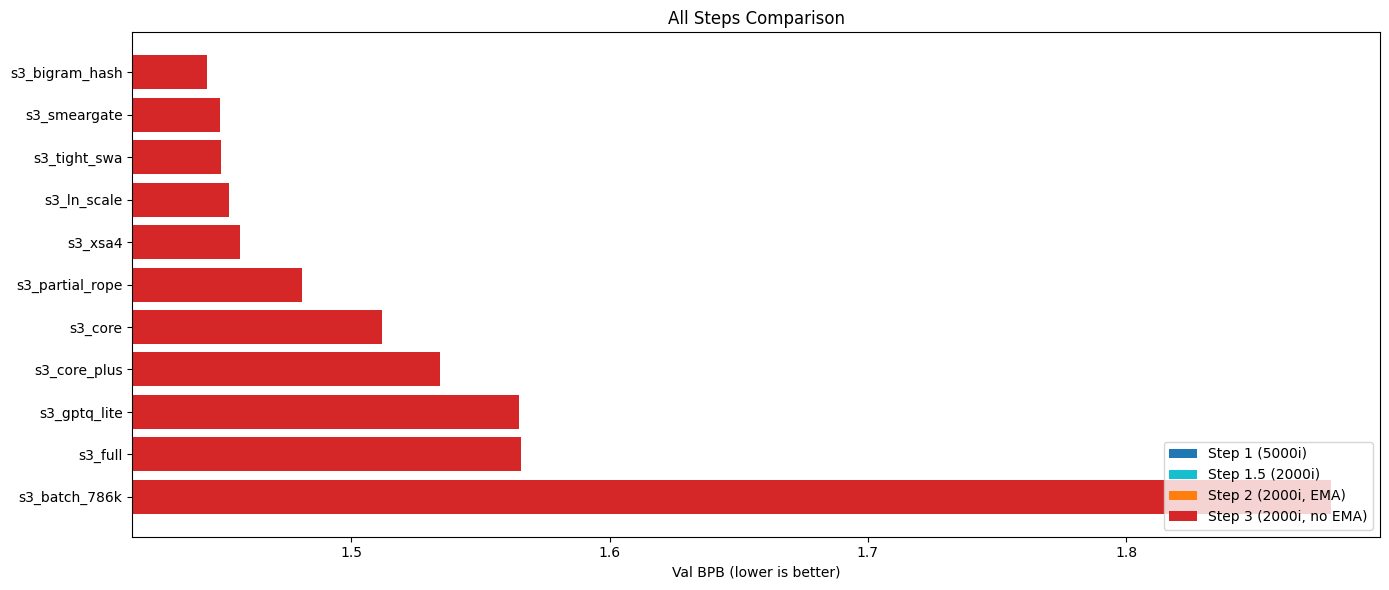

In [9]:
import json as jsonlib
import matplotlib.pyplot as plt

DIRS = {
    "experiments": "Step 1",
    "experiments_step1_5": "Step 1.5",
    "experiments_step2": "Step 2",
    "experiments_step3": "Step 3",
    "/content/drive/MyDrive/parameter-golf-experiments": "Drive S1",
    "/content/drive/MyDrive/parameter-golf-experiments-step1_5": "Drive S1.5",
    "/content/drive/MyDrive/parameter-golf-experiments-step2": "Drive S2",
    "/content/drive/MyDrive/parameter-golf-experiments-step3": "Drive S3",
}

results = {}
for base_dir, label in DIRS.items():
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        r["_source"] = label
        results[r["experiment"]] = r

results = list(results.values())

if not results:
    print("No results found.")
else:
    results.sort(key=lambda r: r.get("val_bpb", 999))
    print(f"{'#':<3} {'Experiment':<25} {'BPB':>8} {'Loss':>8} {'Source':>10}")
    print("-" * 58)
    for i, r in enumerate(results):
        print(f"{i+1:<3} {r['experiment']:<25} {r.get('val_bpb',0):>8.4f} {r.get('val_loss',0):>8.4f} {r.get('_source','?'):>10}")

    fig, ax = plt.subplots(1, 1, figsize=(14, max(6, len(results) * 0.35)))
    names = [r["experiment"] for r in results]
    bpbs = [r.get("val_bpb", 0) for r in results]
    color_map = {"Step 1": "tab:blue", "Step 1.5": "tab:cyan", "Step 2": "tab:orange",
                 "Step 3": "tab:red", "Drive S1": "tab:blue", "Drive S1.5": "tab:cyan",
                 "Drive S2": "tab:orange", "Drive S3": "tab:red"}
    colors = [color_map.get(r.get("_source", ""), "gray") for r in results]

    ax.barh(names, bpbs, color=colors)
    ax.set_xlabel("Val BPB (lower is better)")
    ax.set_title("All Steps Comparison")
    ax.invert_yaxis()
    if bpbs:
        ax.set_xlim(min(bpbs) * 0.98, max(bpbs) * 1.01)
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, fc="tab:blue", label="Step 1 (5000i)"),
        plt.Rectangle((0,0),1,1, fc="tab:cyan", label="Step 1.5 (2000i)"),
        plt.Rectangle((0,0),1,1, fc="tab:orange", label="Step 2 (2000i, EMA)"),
        plt.Rectangle((0,0),1,1, fc="tab:red", label="Step 3 (2000i, no EMA)"),
    ], loc="lower right")
    plt.tight_layout()
    plt.show()

### Save Results to Google Drive

Mount Google Drive and copy all experiment results + logs so they persist after the Colab session ends.

In [11]:
from google.colab import drive
import shutil

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments-step3"
os.makedirs(DRIVE_DIR, exist_ok=True)

copied = []
if os.path.exists("experiments_step3"):
    for exp_name in sorted(os.listdir("experiments_step3")):
        src = f"experiments_step3/{exp_name}"
        dst = f"{DRIVE_DIR}/{exp_name}"
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            copied.append(exp_name)

print(f"Saved to: {DRIVE_DIR}")
print(f"Step 3 experiments copied: {len(copied)}")
for name in copied:
    result_file = f"{DRIVE_DIR}/{name}/result.json"
    if os.path.exists(result_file):
        with open(result_file) as f:
            r = jsonlib.load(f)
        print(f"  {name}: BPB={r.get('val_bpb', '?')}")

Mounted at /content/drive
Saved to: /content/drive/MyDrive/parameter-golf-experiments-step3
Step 3 experiments copied: 11
  s3_batch_786k: BPB=1.8794
  s3_bigram_hash: BPB=1.4442
  s3_core: BPB=1.512
  s3_core_plus: BPB=1.5343
  s3_full: BPB=1.5659
  s3_gptq_lite: BPB=1.5649
  s3_ln_scale: BPB=1.4529
  s3_partial_rope: BPB=1.4809
  s3_smeargate: BPB=1.4492
  s3_tight_swa: BPB=1.4495
  s3_xsa4: BPB=1.4568
